# recycling_ssg — 확장 학습 데이터 YOLO 객체탐지 실험 보고서


1. 데이터 구조·라벨 품질·클래스 균형 감사(audit)
2. JSON 라벨 → Ultralytics YOLO detection 형식 전처리
3. YOLO baseline 작성
4. OpenCV 오프라인 증강과 YOLO 내장 증강 ablation 실험
5. Precision / Recall / mAP50 / mAP50-95 / 학습시간 비교
6. best run의 PR curve·confusion matrix·클래스별 AP 확인
7. 상위 증강 조합 multi-seed 재검증

## 이번 데이터의 사전 분석 핵심 요약

원본 ZIP을 직접 점검한 결과입니다.

| 항목 | 결과 |
|---|---:|
| Training 이미지 | 766 |
| Validation 이미지 | 166 |
| 전체 이미지 | 932 |
| Training 소분류 | 86개: 84개 클래스 × 9장, `의류/기타`·`캔류/기타` 각 5장 |
| Validation 소분류 | 83개 × 각 2장 |
| 의도된 탐지 클래스 | 86 |
| JSON Bounding 객체 | 1,040 |
| BOX | 1,010 |
| POLYGON | 30 |
| exact duplicate 이미지 | 0 |
| train-val exact duplicate | 0 |
| 폴더 목표 클래스가 JSON에 없는 이미지 | 6 |
| 의도된 86개 taxonomy 밖 객체 | 3 (`전자제품/기타`) |
| JSON 해상도 메타데이터와 실제 이미지 불일치 | 4 |
| 주간 | 932 / 932 |
| 실외 | 871 / 932 |

Validation 원본에는 `의류/기타`, `캔류/기타`, `형광등/기타` 세 소분류가 존재하지 않아 해당 세 클래스는 현재 validation에서 AP를 측정할 수 없습니다.


## 전처리 원칙

- 클래스 taxonomy는 **Training 폴더에 존재하는 86개 `대분류/소분류` 조합**으로 고정합니다.
- bbox의 실제 클래스는 폴더명이 아니라 **JSON `Bounding.CLASS` + `Bounding.DETAILS`**를 신뢰합니다.
- 대분류 표기만 `나무류→나무`, `비닐류→비닐`, `스티로폼류→스티로폼`, `유리병류→유리병`, `페트병류→페트병`으로 정규화합니다.
- `POLYGON`은 detection 문제에 맞춰 polygon 전체 점의 최소/최대 좌표로 axis-aligned bbox를 만듭니다.
- 실제 이미지 크기와 JSON `RESOLUTION`이 다르면 **실제 디코딩된 이미지 크기**를 사용합니다.
- 폴더의 목표 클래스가 JSON 안에 존재하지 않는 샘플은 기본값으로 제외합니다. 폴더명을 정답으로 덮어쓰지 않습니다.
- Validation에는 어떤 증강도 적용하지 않습니다.
- 증강 비교에서는 모델·split·epoch·imgsz·batch·seed를 동일하게 고정합니다.

# 0. 공통 설정

`ZIP_PATH`만 실제 프로젝트 위치에 맞으면 됩니다. 이 노트북에는 패키지 설치 명령을 포함하지 않습니다.

In [1]:
from __future__ import annotations

import os
import sys
import json
import math
import time
import random
import shutil
import hashlib
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from IPython.display import display, Image as IPImage, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 현재 대화 환경과 프로젝트 로컬 실행 모두 찾기 쉽게 후보를 둡니다.
ZIP_CANDIDATES = [
    Path("data_train10_val2.zip"),
    Path("data/data_train10_val2.zip"),
    Path("./data/data_train10_val2.zip"),
    Path("/mnt/data/data_train10_val2.zip"),
]
ZIP_PATH = next((p for p in ZIP_CANDIDATES if p.exists()), None)
if ZIP_PATH is None:
    raise FileNotFoundError("data_train10_val2.zip 경로를 ZIP_CANDIDATES에 지정하세요.")

WORK_DIR = Path("yolo_train10_val2_experiment").resolve()
DATASET_DIR = WORK_DIR / "dataset"
REPORT_DIR = WORK_DIR / "reports"
RUNS_DIR = WORK_DIR / "runs"

for p in [WORK_DIR, DATASET_DIR, REPORT_DIR, RUNS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# QA 정책: 폴더 목표 클래스와 JSON 실제 라벨이 불일치하는 샘플은 제외
DROP_TARGET_MISMATCH_IMAGES = True

# YOLO 공통 설정
MODEL_NAME = "yolo26n.pt"
IMGSZ = 640
BATCH = 8
WORKERS = 0          # Windows + Jupyter 안전 설정
EPOCHS = 60
PATIENCE = 30
RUN_TRAINING = False
RUN_MULTISEED = False
MULTI_SEEDS = [42, 123, 777]

# OpenCV offline augmentation은 원본 train 1장당 1장만 생성
CV2_AUG_COPIES = 1

print("ZIP_PATH:", ZIP_PATH.resolve())
print("WORK_DIR:", WORK_DIR)
print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)

ZIP_PATH: /mnt/data/data_train10_val2.zip
WORK_DIR: /mnt/data/nb_train10_exec/yolo_train10_val2_experiment
Python: 3.13.5
OpenCV: 4.13.0


# 1. ZIP 구조와 샘플링 균형 확인

먼저 실제 Training/Validation 샘플 수가 의도한 확장 샘플링대로 구성되어 있는지 폴더 구조와 report를 함께 확인합니다.

In [2]:
with zipfile.ZipFile(ZIP_PATH) as zf:
    zip_members = zf.namelist()

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".webp", ".bmp")
image_members = [n for n in zip_members if n.lower().endswith(IMAGE_EXTS)]
json_members = [n for n in zip_members if n.lower().endswith(".json")]
report_csvs = [n for n in zip_members if "/reports/" in n and n.lower().endswith(".csv")]

print("ZIP entries :", len(zip_members))
print("Images      :", len(image_members))
print("JSON labels :", len(json_members))
print("Report CSVs :", len(report_csvs))

ZIP entries : 4091
Images      : 932
JSON labels : 932
Report CSVs : 6


## 1-1. 샘플링 report 확인

ZIP에 포함된 `subcategory_image_counts.csv`를 읽어 실제 요청/추출 수를 확인합니다. 파일명만 보고 클래스당 10장이라고 가정하지 않고 **실제 생성된 샘플 수**를 기준으로 이후 실험을 진행합니다.

In [3]:
def load_subcategory_report(split: str):
    report_name = next(
        n for n in report_csvs
        if f"/{split}/reports/subcategory_image_counts.csv" in n
    )
    with zipfile.ZipFile(ZIP_PATH) as zf:
        return pd.read_csv(zf.open(report_name))

train_sampling_report = load_subcategory_report("Training")
val_sampling_report = load_subcategory_report("Validation")

print("Training sampled_pairs distribution")
display(train_sampling_report["sampled_pairs"].value_counts().sort_index().rename("subcategory_count").to_frame())

print("Training categories below requested_pairs")
display(
    train_sampling_report.loc[
        train_sampling_report["sampled_pairs"] < train_sampling_report["requested_pairs"],
        ["major_category", "sub_category", "matched_pairs", "requested_pairs", "sampled_pairs"],
    ]
)

print("Validation sampled_pairs distribution")
display(val_sampling_report["sampled_pairs"].value_counts().sort_index().rename("subcategory_count").to_frame())

Training sampled_pairs distribution


,subcategory_count
sampled_pairs,
5,2
9,84


Training categories below requested_pairs


,major_category,sub_category,matched_pairs,requested_pairs,sampled_pairs
45,의류,기타,5,9,5
63,캔류,기타,5,9,5


Validation sampled_pairs distribution


,subcategory_count
sampled_pairs,
2,83


In [4]:
def path_info(member: str):
    parts = Path(member).parts
    # data_train10_val2 / Training|Validation / images|labels / major / detail / group / file
    return {
        "split": parts[1],
        "kind": parts[2],
        "major": parts[3],
        "detail": parts[4],
        "group": parts[5],
        "filename": parts[-1],
    }

folder_rows = []
for n in image_members:
    info = path_info(n)
    folder_rows.append({
        "split": info["split"],
        "major": info["major"],
        "detail": info["detail"],
        "member": n,
    })

folder_df = pd.DataFrame(folder_rows)
folder_counts = (
    folder_df.groupby(["split", "major", "detail"])
    .size()
    .rename("image_count")
    .reset_index()
)

summary = (
    folder_counts.groupby("split")
    .agg(
        subcategories=("detail", "size"),
        min_images=("image_count", "min"),
        max_images=("image_count", "max"),
        mean_images=("image_count", "mean"),
    )
)
display(summary)

print("Image count distribution by subcategory")
display(
    folder_counts.groupby(["split", "image_count"])
    .size()
    .rename("subcategory_count")
    .reset_index()
)

,subcategories,min_images,max_images,mean_images
split,,,,
Training,86,5,9,8.906977
Validation,83,2,2,2.000000


Image count distribution by subcategory


,split,image_count,subcategory_count
0,Training,5,2
1,Training,9,84
2,Validation,2,83


## 1-1. 의도된 86개 클래스 taxonomy

Training의 폴더 구조를 프로젝트의 대상 클래스 목록으로 사용합니다. 같은 세부 이름이 여러 대분류에 존재할 수 있으므로 `대분류/소분류` 조합을 하나의 클래스 이름으로 사용합니다.

In [5]:
CANON_MAJOR = {
    "나무류": "나무",
    "비닐류": "비닐",
    "스티로폼류": "스티로폼",
    "유리병류": "유리병",
    "페트병류": "페트병",
}

def canonical_major(name: str) -> str:
    name = str(name).strip()
    return CANON_MAJOR.get(name, name)

train_target_pairs = (
    folder_counts[folder_counts["split"].eq("Training")]
    .assign(class_name=lambda d: d["major"].map(canonical_major) + "/" + d["detail"])
    ["class_name"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

TARGET_CLASSES = train_target_pairs
CLASS_TO_ID = {name: i for i, name in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

print("Target classes:", len(TARGET_CLASSES))
display(pd.DataFrame({"class_id": range(len(TARGET_CLASSES)), "class_name": TARGET_CLASSES}))

Target classes: 86


,class_id,class_name
0,0,고철류/고철
1,1,고철류/골프채
2,2,고철류/기타
3,3,고철류/비철금속
4,4,고철류/전기프라이팬
5,5,고철류/주전자
6,6,고철류/철옷걸이
7,7,고철류/프라이팬
8,8,나무/기타
9,9,나무/나무행거


In [6]:
val_target_classes = set(
    folder_counts[folder_counts["split"].eq("Validation")]
    .assign(class_name=lambda d: d["major"].map(canonical_major) + "/" + d["detail"])
    ["class_name"]
)

missing_val_target_classes = sorted(set(TARGET_CLASSES) - val_target_classes)
print("Classes absent from Validation folder structure:")
for x in missing_val_target_classes:
    print(" -", x)

Classes absent from Validation folder structure:
 - 의류/기타
 - 캔류/기타
 - 형광등/기타


# 2. JSON 라벨 전체 감사

폴더 샘플링이 균형이어도 실제 객체 라벨은 다를 수 있습니다. 다음을 전부 검사합니다.

- `BoundingCount`와 실제 Bounding 배열 길이
- BOX / POLYGON 비율
- 실제 bbox 클래스와 폴더 목표 클래스
- taxonomy 밖 객체
- 실제 이미지 크기 vs JSON `RESOLUTION`
- 깨진 이미지
- bbox 좌표 유효성
- exact duplicate 및 train-val 누수

In [7]:
def parse_resolution(value: str):
    s = str(value).replace(" ", "")
    for sep in ("*", "x", "X"):
        if sep in s:
            a, b = s.split(sep, 1)
            if a.isdigit() and b.isdigit():
                return int(a), int(b)
    return None, None


def polygon_points_to_xyxy(polygon_points):
    pts = []
    for item in polygon_points or []:
        if not item:
            continue
        raw = next(iter(item.values()))
        x, y = str(raw).split(",")
        pts.append((float(x), float(y)))
    if not pts:
        raise ValueError("PolygonPoint is empty")
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    return min(xs), min(ys), max(xs), max(ys)


def bounding_to_xyxy(b: dict):
    if all(k in b for k in ("x1", "y1", "x2", "y2")):
        return (
            float(b["x1"]), float(b["y1"]),
            float(b["x2"]), float(b["y2"]),
            "BOX",
        )
    if b.get("PolygonPoint"):
        x1, y1, x2, y2 = polygon_points_to_xyxy(b["PolygonPoint"])
        return x1, y1, x2, y2, "POLYGON"
    raise ValueError("No BOX coordinates or PolygonPoint")


def json_to_image_member(json_member: str) -> str:
    return json_member.replace("/labels/", "/images/").rsplit(".", 1)[0] + ".jpg"


def clip_xyxy(x1, y1, x2, y2, width, height):
    return (
        float(np.clip(x1, 0, width)),
        float(np.clip(y1, 0, height)),
        float(np.clip(x2, 0, width)),
        float(np.clip(y2, 0, height)),
    )

In [8]:
image_rows = []
object_rows = []
audit_errors = []

with zipfile.ZipFile(ZIP_PATH) as zf:
    name_set = set(zf.namelist())

    for json_member in sorted(json_members):
        p = path_info(json_member)
        target_class = f'{canonical_major(p["major"])}/{p["detail"]}'
        image_member = json_to_image_member(json_member)

        if image_member not in name_set:
            audit_errors.append({"json_member": json_member, "error": "missing image"})
            continue

        image_bytes = zf.read(image_member)
        image_sha1 = hashlib.sha1(image_bytes).hexdigest()
        image = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)
        if image is None:
            audit_errors.append({"json_member": json_member, "error": "cv2.imdecode failed"})
            continue

        h, w = image.shape[:2]
        payload = json.load(zf.open(json_member))
        meta_w, meta_h = parse_resolution(payload.get("RESOLUTION", ""))
        bounds = payload.get("Bounding") or []
        declared_count = int(payload.get("BoundingCount", len(bounds)))

        actual_classes = []
        valid_objects = 0

        for object_idx, b in enumerate(bounds):
            try:
                x1, y1, x2, y2, geometry = bounding_to_xyxy(b)
                raw = (x1, y1, x2, y2)
                x1, y1, x2, y2 = clip_xyxy(x1, y1, x2, y2, w, h)
                valid = x2 > x1 and y2 > y1
                if not valid:
                    raise ValueError(f"invalid bbox after clip: {(x1, y1, x2, y2)}")

                major = canonical_major(b.get("CLASS", "UNKNOWN"))
                detail = str(b.get("DETAILS", "UNKNOWN")).strip()
                class_name = f"{major}/{detail}"
                actual_classes.append(class_name)
                valid_objects += 1

                object_rows.append({
                    "split": p["split"],
                    "image_member": image_member,
                    "json_member": json_member,
                    "target_class": target_class,
                    "object_idx": object_idx,
                    "class_name": class_name,
                    "in_target_taxonomy": class_name in CLASS_TO_ID,
                    "geometry": geometry,
                    "width": w,
                    "height": h,
                    "raw_x1": raw[0],
                    "raw_y1": raw[1],
                    "raw_x2": raw[2],
                    "raw_y2": raw[3],
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "bbox_area_ratio": ((x2 - x1) * (y2 - y1)) / (w * h),
                    "bbox_aspect_ratio": (x2 - x1) / (y2 - y1),
                    "was_clipped": raw != (x1, y1, x2, y2),
                })
            except Exception as e:
                audit_errors.append({
                    "json_member": json_member,
                    "object_idx": object_idx,
                    "error": repr(e),
                })

        image_rows.append({
            "split": p["split"],
            "major_folder": p["major"],
            "detail_folder": p["detail"],
            "target_class": target_class,
            "image_member": image_member,
            "json_member": json_member,
            "image_name": Path(image_member).name,
            "width": w,
            "height": h,
            "meta_width": meta_w,
            "meta_height": meta_h,
            "resolution_match": (w == meta_w and h == meta_h),
            "objects": valid_objects,
            "declared_bounding_count": declared_count,
            "bounding_count_match": declared_count == len(bounds),
            "target_present_in_json": target_class in actual_classes,
            "actual_classes": " | ".join(actual_classes),
            "day_night": payload.get("DAY/NIGHT"),
            "place": payload.get("PLACE"),
            "sha1": image_sha1,
        })

image_df = pd.DataFrame(image_rows)
object_df = pd.DataFrame(object_rows)
audit_error_df = pd.DataFrame(audit_errors)

print("Audited images :", len(image_df))
print("Audited objects:", len(object_df))
print("Audit errors   :", len(audit_error_df))

Audited images : 932
Audited objects: 1040
Audit errors   : 0


## 2-1. 핵심 QA 요약

In [9]:
qa = pd.Series({
    "raw_images": len(image_df),
    "raw_objects": len(object_df),
    "box_objects": int(object_df["geometry"].eq("BOX").sum()),
    "polygon_objects": int(object_df["geometry"].eq("POLYGON").sum()),
    "invalid_or_parse_errors": len(audit_error_df),
    "bounding_count_mismatch_images": int((~image_df["bounding_count_match"]).sum()),
    "resolution_mismatch_images": int((~image_df["resolution_match"]).sum()),
    "target_label_mismatch_images": int((~image_df["target_present_in_json"]).sum()),
    "out_of_taxonomy_objects": int((~object_df["in_target_taxonomy"]).sum()),
    "exact_duplicate_rows": int(image_df.duplicated("sha1", keep=False).sum()),
}, name="value")

display(qa.to_frame())

cross_split_dup_groups = (
    image_df.groupby("sha1")["split"].nunique().loc[lambda s: s > 1]
)
print("Train/Validation exact duplicate groups:", len(cross_split_dup_groups))

,value
raw_images,932
raw_objects,1040
box_objects,1010
polygon_objects,30
invalid_or_parse_errors,0
bounding_count_mismatch_images,0
resolution_mismatch_images,4
target_label_mismatch_images,6
out_of_taxonomy_objects,3
exact_duplicate_rows,0


Train/Validation exact duplicate groups: 0


## 2-2. 폴더 목표 클래스와 JSON 실제 라벨 불일치

이 파일들은 폴더명으로 강제 재라벨링하지 않습니다. 기본 정책에서는 YOLO 데이터셋 생성 시 제외합니다.

In [10]:
target_mismatch_df = image_df.loc[
    ~image_df["target_present_in_json"],
    ["split", "target_class", "image_name", "json_member", "actual_classes"],
].copy()

display(target_mismatch_df)

,split,target_class,image_name,json_member,actual_classes
158,Training,도기류/기타,14_X044_C045_0128_4.jpg,data_train10_val2/Training/labels/도기류/기타/14_X0...,도기류/그릇류 | 전자제품/기타
160,Training,도기류/기타,14_X047_C045_0128_0.jpg,data_train10_val2/Training/labels/도기류/기타/14_X0...,도기류/그릇류 | 전자제품/기타
161,Training,도기류/기타,14_X051_C045_0128_3.jpg,data_train10_val2/Training/labels/도기류/기타/14_X0...,도기류/그릇류 | 전자제품/기타
250,Training,비닐/기타,15_X071_C205_1206_1.jpg,data_train10_val2/Training/labels/비닐/기타/15_X07...,비닐/과자봉지
251,Training,비닐/기타,15_X071_C205_1206_3.jpg,data_train10_val2/Training/labels/비닐/기타/15_X07...,비닐/과자봉지
807,Validation,도기류/병,14_X004_C163_1203_4.jpg,data_train10_val2/Validation/labels/도기류/병/14_X...,도기류/그릇류


## 2-3. 86개 대상 taxonomy 밖의 객체

현재 데이터에는 선택 대상이 아닌 `전자제품/기타` 객체가 1개 포함되어 있습니다. 이 객체가 포함된 이미지는 동시에 폴더 목표 클래스도 누락된 QA 이상 샘플이므로 기본 제외 정책에서 함께 제거됩니다.

In [11]:
out_of_taxonomy_df = object_df.loc[
    ~object_df["in_target_taxonomy"],
    ["split", "image_member", "target_class", "class_name", "geometry", "x1", "y1", "x2", "y2"],
].copy()

display(out_of_taxonomy_df)

,split,image_member,target_class,class_name,geometry,x1,y1,x2,y2
187,Training,data_train10_val2/Training/images/도기류/기타/14_X0...,도기류/기타,전자제품/기타,BOX,1219.0,496.0,1572.0,760.0
191,Training,data_train10_val2/Training/images/도기류/기타/14_X0...,도기류/기타,전자제품/기타,BOX,273.0,578.0,616.0,921.0
193,Training,data_train10_val2/Training/images/도기류/기타/14_X0...,도기류/기타,전자제품/기타,BOX,1041.0,308.0,1474.0,583.0


## 2-4. 해상도 메타데이터 불일치

좌표 정규화는 JSON 메타데이터가 아니라 실제 디코딩한 이미지 크기를 사용하므로 두 사례도 안전하게 처리됩니다.

In [12]:
resolution_mismatch_df = image_df.loc[
    ~image_df["resolution_match"],
    ["split", "image_name", "width", "height", "meta_width", "meta_height", "json_member"],
].copy()

display(resolution_mismatch_df)

,split,image_name,width,height,meta_width,meta_height,json_member
591,Training,22_X017_C509_0512_0.jpg,1440,1921,1921,1440,data_train10_val2/Training/labels/캔류/음료수캔/22_X...
622,Training,23_X004_C509_0511_1.jpg,1440,1921,1921,1440,data_train10_val2/Training/labels/페트병/기타/23_X0...
624,Training,23_X013_C509_0511_4.jpg,1440,1921,1921,1440,data_train10_val2/Training/labels/페트병/기타/23_X0...
628,Training,23_X020_C509_0511_0.jpg,1440,1921,1921,1440,data_train10_val2/Training/labels/페트병/기타/23_X0...


# 3. 클래스 균형 분석

이번 샘플링은 대부분 Training 소분류당 9장, Validation 소분류당 2장입니다. 한 이미지에 여러 bbox가 존재하므로 **실제 객체 수**는 폴더 이미지 수와 정확히 같지 않을 수 있습니다.

In [13]:
# 폴더 기준 target 이미지 수
folder_balance = (
    image_df.groupby(["target_class", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(TARGET_CLASSES, fill_value=0)
)
folder_balance = folder_balance.reindex(columns=["Training", "Validation"], fill_value=0)

# JSON 객체 기준 실제 bbox 수: 의도된 86개 taxonomy만
object_support = (
    object_df[object_df["in_target_taxonomy"]]
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(TARGET_CLASSES, fill_value=0)
)
object_support = object_support.reindex(columns=["Training", "Validation"], fill_value=0)
object_support["total"] = object_support["Training"] + object_support["Validation"]

print("Folder-level image balance")
display(folder_balance.describe())
print("Object-level bbox support")
display(object_support.describe())

Folder-level image balance


split,Training,Validation
count,86.000000,86.000000
mean,8.906977,1.930233
std,0.606395,0.369123
min,5.000000,0.000000
25%,9.000000,2.000000
50%,9.000000,2.000000
75%,9.000000,2.000000
max,9.000000,2.000000


Object-level bbox support


split,Training,Validation,total
count,86.000000,86.000000,86.000000
mean,9.976744,2.081395,12.058140
std,2.243824,0.598333,2.531471
min,5.000000,0.000000,5.000000
25%,9.000000,2.000000,11.000000
50%,9.000000,2.000000,11.000000
75%,10.000000,2.000000,12.000000
max,18.000000,4.000000,22.000000


In [14]:
def coefficient_of_variation(values):
    values = np.asarray(values, dtype=float)
    mean = values.mean()
    return float(values.std(ddof=1) / mean) if mean else np.nan

balance_metrics = pd.DataFrame([
    {
        "basis": "folder images",
        "split": "Training",
        "classes": len(TARGET_CLASSES),
        "min": folder_balance["Training"].min(),
        "max": folder_balance["Training"].max(),
        "mean": folder_balance["Training"].mean(),
        "CV": coefficient_of_variation(folder_balance["Training"]),
        "zero_classes": int(folder_balance["Training"].eq(0).sum()),
    },
    {
        "basis": "folder images",
        "split": "Validation",
        "classes": len(TARGET_CLASSES),
        "min": folder_balance["Validation"].min(),
        "max": folder_balance["Validation"].max(),
        "mean": folder_balance["Validation"].mean(),
        "CV": coefficient_of_variation(folder_balance["Validation"]),
        "zero_classes": int(folder_balance["Validation"].eq(0).sum()),
    },
    {
        "basis": "JSON bbox objects",
        "split": "Training",
        "classes": len(TARGET_CLASSES),
        "min": object_support["Training"].min(),
        "max": object_support["Training"].max(),
        "mean": object_support["Training"].mean(),
        "CV": coefficient_of_variation(object_support["Training"]),
        "zero_classes": int(object_support["Training"].eq(0).sum()),
    },
    {
        "basis": "JSON bbox objects",
        "split": "Validation",
        "classes": len(TARGET_CLASSES),
        "min": object_support["Validation"].min(),
        "max": object_support["Validation"].max(),
        "mean": object_support["Validation"].mean(),
        "CV": coefficient_of_variation(object_support["Validation"]),
        "zero_classes": int(object_support["Validation"].eq(0).sum()),
    },
])

display(balance_metrics)

,basis,split,classes,min,max,mean,CV,zero_classes
0,folder images,Training,86,5,9,8.906977,0.068081,0
1,folder images,Validation,86,0,2,1.930233,0.191232,3
2,JSON bbox objects,Training,86,5,18,9.976744,0.224905,0
3,JSON bbox objects,Validation,86,0,4,2.081395,0.287467,3


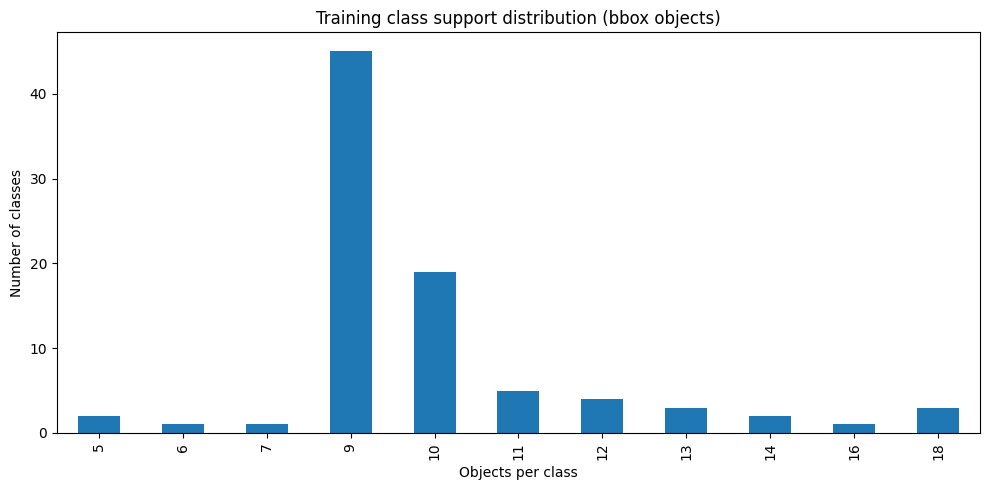

In [15]:
plt.figure(figsize=(10, 5))
object_support["Training"].value_counts().sort_index().plot(kind="bar")
plt.title("Training class support distribution (bbox objects)")
plt.xlabel("Objects per class")
plt.ylabel("Number of classes")
plt.tight_layout()
plt.show()

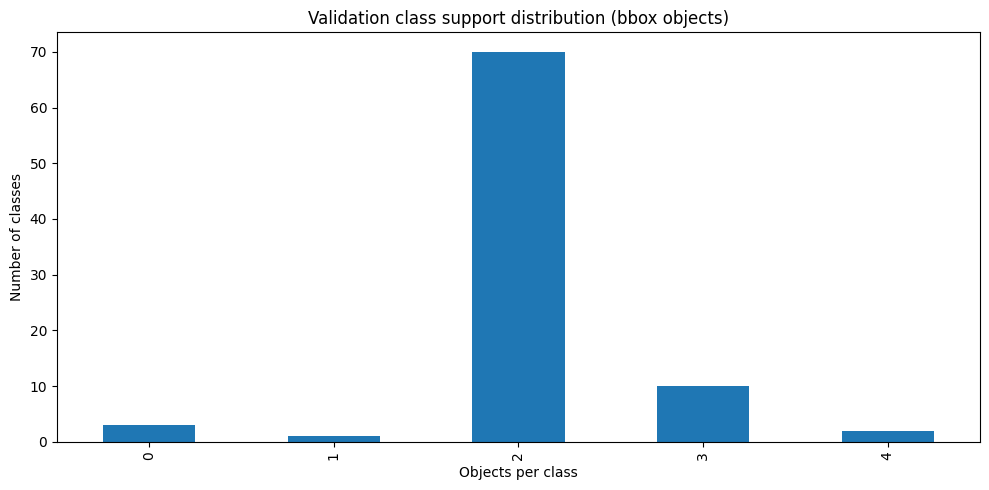

In [16]:
plt.figure(figsize=(10, 5))
object_support["Validation"].value_counts().sort_index().plot(kind="bar")
plt.title("Validation class support distribution (bbox objects)")
plt.xlabel("Objects per class")
plt.ylabel("Number of classes")
plt.tight_layout()
plt.show()

split,Training,Validation
major,,
고철류,72,16
나무,72,16
도기류,90,20
비닐,63,14
스티로폼,36,8
유리병,72,16
의류,77,16
종이류,81,18
캔류,59,12


/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 52384 (\N{HANGUL SYLLABLE CEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/1196776473.py:17: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layou

<Figure size 1100x600 with 0 Axes>

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52384 (\N{HANGUL SYLLABLE CEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/o

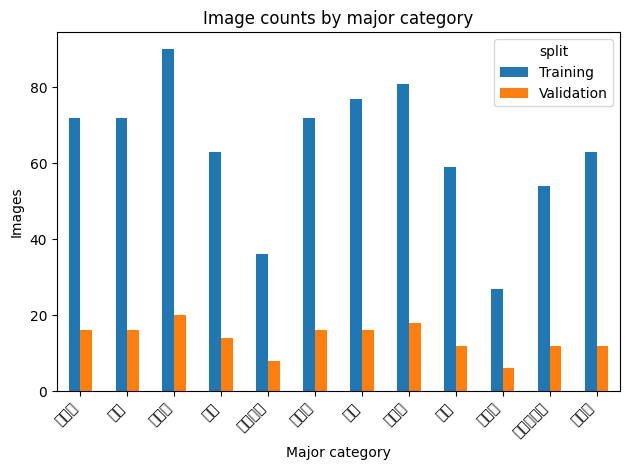

In [17]:
major_counts = (
    folder_df.assign(major=lambda d: d["major"].map(canonical_major))
    .groupby(["major", "split"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(major_counts)

plt.figure(figsize=(11, 6))
major_counts.plot(kind="bar")
plt.title("Image counts by major category")
plt.xlabel("Major category")
plt.ylabel("Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4. 이미지·bbox 분포 EDA

In [18]:
place_counts = image_df["place"].value_counts(dropna=False).rename("images").to_frame()
day_counts = image_df["day_night"].value_counts(dropna=False).rename("images").to_frame()

print("Place")
display(place_counts)
print("Day/Night")
display(day_counts)

Place


,images
place,
실외,871
실내,61


Day/Night


,images
day_night,
주간,932


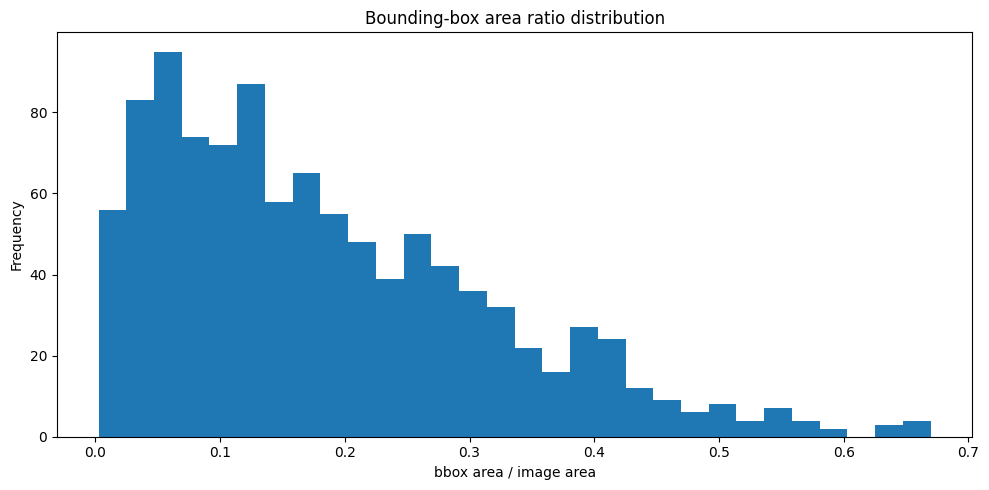

,bbox_area_ratio
count,1040.000000
mean,0.185998
std,0.134271
min,0.002598
1%,0.008984
5%,0.023676
10%,0.037625
25%,0.077273
50%,0.156975
75%,0.268130


In [19]:
plt.figure(figsize=(10, 5))
object_df["bbox_area_ratio"].plot(kind="hist", bins=30)
plt.title("Bounding-box area ratio distribution")
plt.xlabel("bbox area / image area")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(
    object_df["bbox_area_ratio"].describe(
        percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]
    ).to_frame()
)

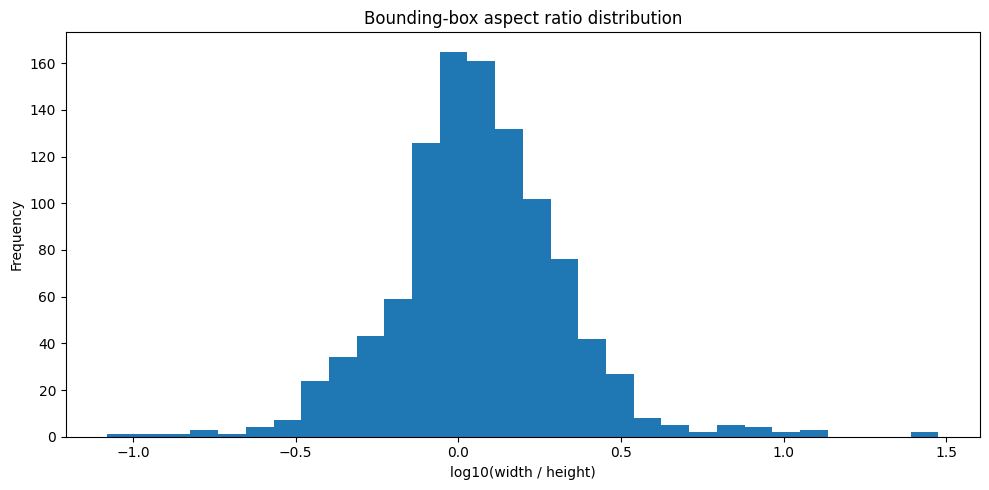

In [20]:
plt.figure(figsize=(10, 5))
np.log10(object_df["bbox_aspect_ratio"].clip(lower=1e-4)).plot(kind="hist", bins=30)
plt.title("Bounding-box aspect ratio distribution")
plt.xlabel("log10(width / height)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 5. JSON → YOLO detection 전처리

생성 구조:

```text
yolo_train10_val2_experiment/
├─ dataset/
│  ├─ images/train
│  ├─ images/val
│  ├─ labels/train
│  ├─ labels/val
│  ├─ data.yaml
│  ├─ class_mapping.csv
│  ├─ image_report.csv
│  ├─ object_report.csv
│  └─ excluded_images.csv
├─ reports/
└─ runs/
```

`DROP_TARGET_MISMATCH_IMAGES=True`인 기본 설정에서는 폴더 목표 클래스가 JSON에 없는 QA 불일치 6장을 제외합니다. 원본 ZIP은 수정하지 않습니다.

In [21]:
def xyxy_to_yolo(x1, y1, x2, y2, width, height):
    xc = ((x1 + x2) / 2.0) / width
    yc = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return xc, yc, bw, bh


def preprocess_to_yolo(overwrite=True):
    if overwrite:
        shutil.rmtree(DATASET_DIR / "images", ignore_errors=True)
        shutil.rmtree(DATASET_DIR / "labels", ignore_errors=True)

    for split in ("train", "val"):
        (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    excluded_rows = []
    processed_image_rows = []
    processed_object_rows = []

    # QA audit 결과를 lookup으로 재사용
    image_lookup = image_df.set_index("json_member").to_dict("index")
    objects_by_json = {k: g.copy() for k, g in object_df.groupby("json_member")}

    with zipfile.ZipFile(ZIP_PATH) as zf:
        for json_member in sorted(json_members):
            audit = image_lookup[json_member]
            split = "train" if audit["split"] == "Training" else "val"

            if DROP_TARGET_MISMATCH_IMAGES and not audit["target_present_in_json"]:
                excluded_rows.append({
                    "split": split,
                    "image_name": audit["image_name"],
                    "target_class": audit["target_class"],
                    "actual_classes": audit["actual_classes"],
                    "reason": "folder target class absent from JSON Bounding labels",
                })
                continue

            image_member = audit["image_member"]
            image_bytes = zf.read(image_member)
            out_img = DATASET_DIR / "images" / split / audit["image_name"]
            out_img.write_bytes(image_bytes)

            g = objects_by_json.get(json_member, pd.DataFrame())
            yolo_lines = []
            kept_objects = 0

            for _, obj in g.iterrows():
                # 프로젝트의 86개 대상 taxonomy 외 객체는 YOLO class head에 넣지 않음
                if not bool(obj["in_target_taxonomy"]):
                    continue

                class_id = CLASS_TO_ID[obj["class_name"]]
                xc, yc, bw, bh = xyxy_to_yolo(
                    obj["x1"], obj["y1"], obj["x2"], obj["y2"],
                    int(obj["width"]), int(obj["height"]),
                )
                values = np.array([xc, yc, bw, bh], dtype=float)
                if not np.all((values >= 0) & (values <= 1)):
                    raise ValueError(f"normalized bbox out of range: {json_member} {values}")

                yolo_lines.append(
                    f"{class_id} {xc:.8f} {yc:.8f} {bw:.8f} {bh:.8f}"
                )
                kept_objects += 1
                obj_row = obj.to_dict()
                obj_row["processed_split"] = split
                obj_row["image_name"] = audit["image_name"]
                processed_object_rows.append(obj_row)

            out_lbl = DATASET_DIR / "labels" / split / f'{Path(audit["image_name"]).stem}.txt'
            out_lbl.write_text("\n".join(yolo_lines), encoding="utf-8")

            processed_image_rows.append({
                **audit,
                "processed_split": split,
                "kept_objects": kept_objects,
            })

    processed_image_df = pd.DataFrame(processed_image_rows)
    processed_object_df = pd.DataFrame(processed_object_rows)
    excluded_df = pd.DataFrame(excluded_rows)

    mapping_df = pd.DataFrame({
        "class_id": range(len(TARGET_CLASSES)),
        "class_name": TARGET_CLASSES,
    })

    processed_image_df.to_csv(DATASET_DIR / "image_report.csv", index=False, encoding="utf-8-sig")
    processed_object_df.to_csv(DATASET_DIR / "object_report.csv", index=False, encoding="utf-8-sig")
    excluded_df.to_csv(DATASET_DIR / "excluded_images.csv", index=False, encoding="utf-8-sig")
    mapping_df.to_csv(DATASET_DIR / "class_mapping.csv", index=False, encoding="utf-8-sig")

    data_yaml = {
        "path": str(DATASET_DIR.resolve()),
        "train": "images/train",
        "val": "images/val",
        "names": {i: name for i, name in enumerate(TARGET_CLASSES)},
    }
    with open(DATASET_DIR / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, allow_unicode=True, sort_keys=False)

    return processed_image_df, processed_object_df, excluded_df

processed_image_df, processed_object_df, excluded_df = preprocess_to_yolo(overwrite=True)

print("Processed images:", len(processed_image_df))
print("Processed objects:", len(processed_object_df))
print("Excluded images:", len(excluded_df))
display(processed_image_df.groupby("processed_split").agg(images=("image_name", "count"), objects=("kept_objects", "sum")))
display(excluded_df)

Processed images: 926
Processed objects: 1031
Excluded images: 6


,images,objects
processed_split,,
train,761,853
val,165,178


,split,image_name,target_class,actual_classes,reason
0,train,14_X044_C045_0128_4.jpg,도기류/기타,도기류/그릇류 | 전자제품/기타,folder target class absent from JSON Bounding ...
1,train,14_X047_C045_0128_0.jpg,도기류/기타,도기류/그릇류 | 전자제품/기타,folder target class absent from JSON Bounding ...
2,train,14_X051_C045_0128_3.jpg,도기류/기타,도기류/그릇류 | 전자제품/기타,folder target class absent from JSON Bounding ...
3,train,15_X071_C205_1206_1.jpg,비닐/기타,비닐/과자봉지,folder target class absent from JSON Bounding ...
4,train,15_X071_C205_1206_3.jpg,비닐/기타,비닐/과자봉지,folder target class absent from JSON Bounding ...
5,val,14_X004_C163_1203_4.jpg,도기류/병,도기류/그릇류,folder target class absent from JSON Bounding ...


## 5-1. 전처리 결과 QA

In [22]:
def image_files(split):
    return sorted((DATASET_DIR / "images" / split).glob("*.*"))

def label_files(split):
    return sorted((DATASET_DIR / "labels" / split).glob("*.txt"))

processed_qa = pd.Series({
    "train_images": len(image_files("train")),
    "val_images": len(image_files("val")),
    "train_label_files": len(label_files("train")),
    "val_label_files": len(label_files("val")),
    "processed_objects": len(processed_object_df),
    "processed_classes": processed_object_df["class_name"].nunique(),
    "polygon_to_bbox_objects": int(processed_object_df["geometry"].eq("POLYGON").sum()),
    "excluded_images": len(excluded_df),
    "unexpected_taxonomy_objects_after_processing": int((~processed_object_df["in_target_taxonomy"]).sum()),
}, name="value")

display(processed_qa.to_frame())

assert len(image_files("train")) == len(label_files("train"))
assert len(image_files("val")) == len(label_files("val"))
assert set(processed_object_df["class_name"]).issubset(set(TARGET_CLASSES))
assert not processed_object_df[["x1", "y1", "x2", "y2"]].isna().any().any()

print("Preprocessing QA assertions: PASSED")

,value
train_images,761
val_images,165
train_label_files,761
val_label_files,165
processed_objects,1031
processed_classes,86
polygon_to_bbox_objects,30
excluded_images,6
unexpected_taxonomy_objects_after_processing,0


Preprocessing QA assertions: PASSED


## 5-2. 전처리 후 실제 class support

증강 실험 결과를 해석할 때 이 support를 반드시 같이 봅니다.

In [23]:
processed_support = (
    processed_object_df.groupby(["class_name", "processed_split"])
    .size()
    .unstack(fill_value=0)
    .reindex(TARGET_CLASSES, fill_value=0)
    .reindex(columns=["train", "val"], fill_value=0)
)
processed_support["total"] = processed_support["train"] + processed_support["val"]
processed_support["val_missing"] = processed_support["val"].eq(0)
processed_support["train_low_le4"] = processed_support["train"].le(4)

print("Classes absent from processed validation:", int(processed_support["val_missing"].sum()))
display(processed_support.sort_values(["val", "train", "total"]).head(20))

Classes absent from processed validation: 3


processed_split,train,val,total,val_missing,train_low_le4
class_name,,,,,
의류/기타,5,0,5,True,False
캔류/기타,5,0,5,True,False
형광등/기타,14,0,14,True,False
도기류/병,10,1,11,False,False
도기류/기타,6,2,8,False,False
비닐/기타,7,2,9,False,False
고철류/골프채,9,2,11,False,False
고철류/비철금속,9,2,11,False,False
고철류/전기프라이팬,9,2,11,False,False


# 6. YOLO 라벨 시각 검증

bbox를 다시 픽셀 좌표로 복원해 이미지 위에 그려 전처리 오류가 없는지 확인합니다.

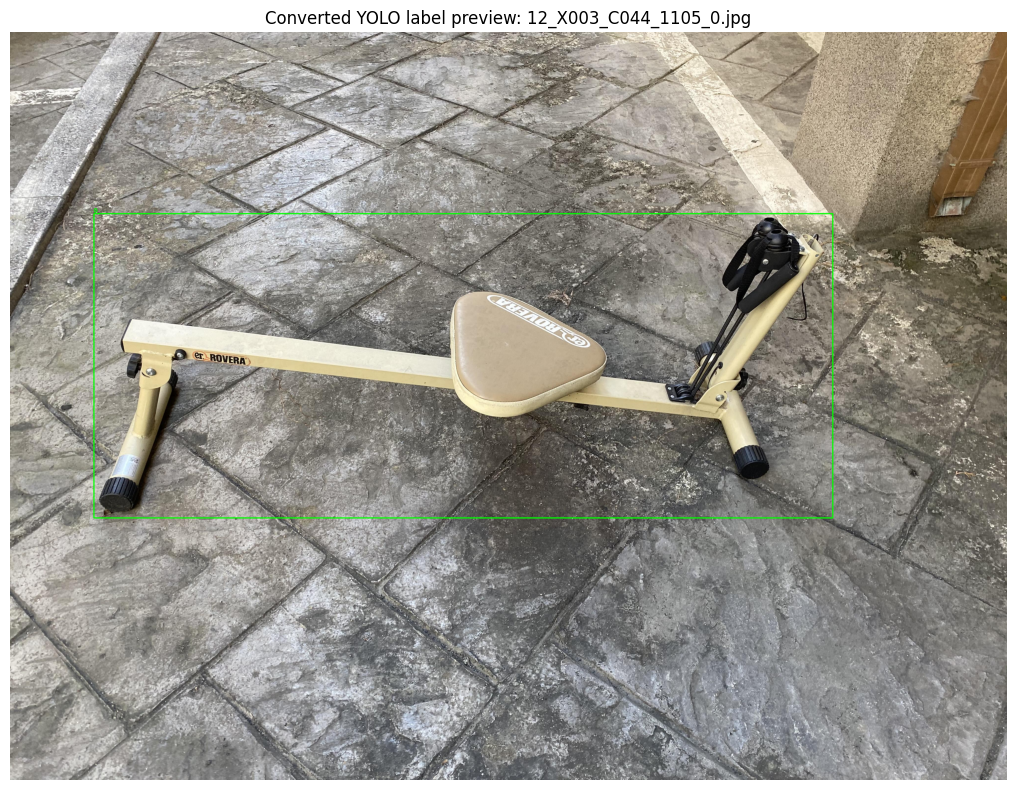

,class_id,class_name
0,0,고철류/고철


In [24]:
def read_yolo_label(label_path: Path, width: int, height: int):
    classes, boxes = [], []
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return np.empty((0,), dtype=int), np.empty((0, 4), dtype=np.float32)

    for line in text.splitlines():
        cls, xc, yc, bw, bh = line.split()
        cls = int(cls)
        xc, yc, bw, bh = map(float, [xc, yc, bw, bh])
        x1 = (xc - bw / 2) * width
        y1 = (yc - bh / 2) * height
        x2 = (xc + bw / 2) * width
        y2 = (yc + bh / 2) * height
        classes.append(cls)
        boxes.append([x1, y1, x2, y2])

    return np.asarray(classes, dtype=int), np.asarray(boxes, dtype=np.float32)


def draw_boxes(image_bgr, boxes, classes, thickness=3):
    out = image_bgr.copy()
    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), thickness)
        # OpenCV 기본 폰트는 한글 미지원이므로 class id만 이미지에 표시
        cv2.putText(
            out, str(int(cls)), (x1, max(20, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA
        )
    return out

# POLYGON이 있었던 processed sample을 우선 선택
poly_candidates = processed_object_df[processed_object_df["geometry"].eq("POLYGON")]
if len(poly_candidates):
    sample_name = Path(poly_candidates.iloc[0]["image_member"]).name
    sample_split = poly_candidates.iloc[0]["processed_split"]
else:
    sample_name = processed_image_df.iloc[0]["image_name"]
    sample_split = processed_image_df.iloc[0]["processed_split"]

img_path = DATASET_DIR / "images" / sample_split / sample_name
lbl_path = DATASET_DIR / "labels" / sample_split / f"{Path(sample_name).stem}.txt"

img = cv2.imread(str(img_path))
h, w = img.shape[:2]
classes, boxes = read_yolo_label(lbl_path, w, h)
preview = draw_boxes(img, boxes, classes)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Converted YOLO label preview: {sample_name}")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "class_id": classes,
    "class_name": [ID_TO_CLASS[int(c)] for c in classes],
}))

# 7. OpenCV 오프라인 증강 구현

## 실험할 OpenCV 계열

### Photometric
bbox 위치는 그대로 유지합니다.

- brightness / contrast
- CLAHE
- Gaussian blur
- Gaussian noise

### Geometric
이미지와 bbox 네 모서리에 동일한 변환을 적용합니다.

- rotation
- translation
- scale
- perspective
- horizontal flip

이미지 밖으로 잘린 bbox는 clip하고, 변환 후 보이는 면적이 원래 변환 bbox의 25% 미만이면 제거합니다.

In [25]:
def bbox_area_xyxy(boxes: np.ndarray):
    if len(boxes) == 0:
        return np.empty((0,), dtype=np.float32)
    return (
        np.clip(boxes[:, 2] - boxes[:, 0], 0, None)
        * np.clip(boxes[:, 3] - boxes[:, 1], 0, None)
    )


def transform_boxes(boxes, matrix, width, height, min_visible=0.25, min_size=2.0):
    if len(boxes) == 0:
        return boxes.copy(), np.empty((0,), dtype=bool), np.empty((0,), dtype=np.float32)

    n = len(boxes)
    corners = np.stack([
        boxes[:, [0, 1]],
        boxes[:, [2, 1]],
        boxes[:, [2, 3]],
        boxes[:, [0, 3]],
    ], axis=1).astype(np.float32)

    pts = corners.reshape(-1, 1, 2)
    if matrix.shape == (2, 3):
        transformed = cv2.transform(pts, matrix).reshape(n, 4, 2)
    else:
        transformed = cv2.perspectiveTransform(pts, matrix).reshape(n, 4, 2)

    raw = np.column_stack([
        transformed[:, :, 0].min(axis=1),
        transformed[:, :, 1].min(axis=1),
        transformed[:, :, 0].max(axis=1),
        transformed[:, :, 1].max(axis=1),
    ]).astype(np.float32)

    raw_area = bbox_area_xyxy(raw)
    clipped = raw.copy()
    clipped[:, [0, 2]] = np.clip(clipped[:, [0, 2]], 0, width)
    clipped[:, [1, 3]] = np.clip(clipped[:, [1, 3]], 0, height)
    clipped_area = bbox_area_xyxy(clipped)
    visible = clipped_area / np.maximum(raw_area, 1e-6)

    keep = (
        ((clipped[:, 2] - clipped[:, 0]) >= min_size)
        & ((clipped[:, 3] - clipped[:, 1]) >= min_size)
        & (visible >= min_visible)
    )
    return clipped[keep], keep, visible


def aug_photo(image, boxes, classes, rng):
    out = image.copy()
    alpha = float(rng.uniform(0.80, 1.20))
    beta = float(rng.uniform(-25, 25))
    out = np.clip(out.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    if rng.random() < 0.40:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=float(rng.uniform(1.5, 3.0)), tileGridSize=(8, 8))
        l = clahe.apply(l)
        out = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    if rng.random() < 0.25:
        k = int(rng.choice([3, 5]))
        out = cv2.GaussianBlur(out, (k, k), 0)

    if rng.random() < 0.30:
        sigma = float(rng.uniform(3, 12))
        noise = rng.normal(0, sigma, out.shape).astype(np.float32)
        out = np.clip(out.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return out, boxes.copy(), classes.copy()


def aug_geo(image, boxes, classes, rng):
    h, w = image.shape[:2]
    angle = float(rng.uniform(-12, 12))
    scale = float(rng.uniform(0.88, 1.12))
    tx = float(rng.uniform(-0.06, 0.06) * w)
    ty = float(rng.uniform(-0.06, 0.06) * h)

    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    matrix[0, 2] += tx
    matrix[1, 2] += ty

    out = cv2.warpAffine(
        image, matrix, (w, h), flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )
    new_boxes, keep, _ = transform_boxes(boxes, matrix, w, h)
    new_classes = classes[keep]

    if rng.random() < 0.35:
        jitter = 0.035
        src = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32)
        dst = src.copy()
        dst[:, 0] += rng.uniform(-jitter*w, jitter*w, 4)
        dst[:, 1] += rng.uniform(-jitter*h, jitter*h, 4)
        pm = cv2.getPerspectiveTransform(src, dst.astype(np.float32))
        out = cv2.warpPerspective(
            out, pm, (w, h), flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101,
        )
        new_boxes, keep2, _ = transform_boxes(new_boxes, pm, w, h)
        new_classes = new_classes[keep2]

    if rng.random() < 0.50:
        out = cv2.flip(out, 1)
        flipped = new_boxes.copy()
        if len(flipped):
            old_x1 = new_boxes[:, 0].copy()
            old_x2 = new_boxes[:, 2].copy()
            flipped[:, 0] = w - old_x2
            flipped[:, 2] = w - old_x1
        new_boxes = flipped

    return out, new_boxes, new_classes


def aug_combined(image, boxes, classes, rng):
    out, b, c = aug_photo(image, boxes, classes, rng)
    out, b, c = aug_geo(out, b, c, rng)
    return out, b, c

CV2_POLICIES = {
    "photo": aug_photo,
    "geo": aug_geo,
    "combined": aug_combined,
}

## 7-1. OpenCV 증강 시각 비교

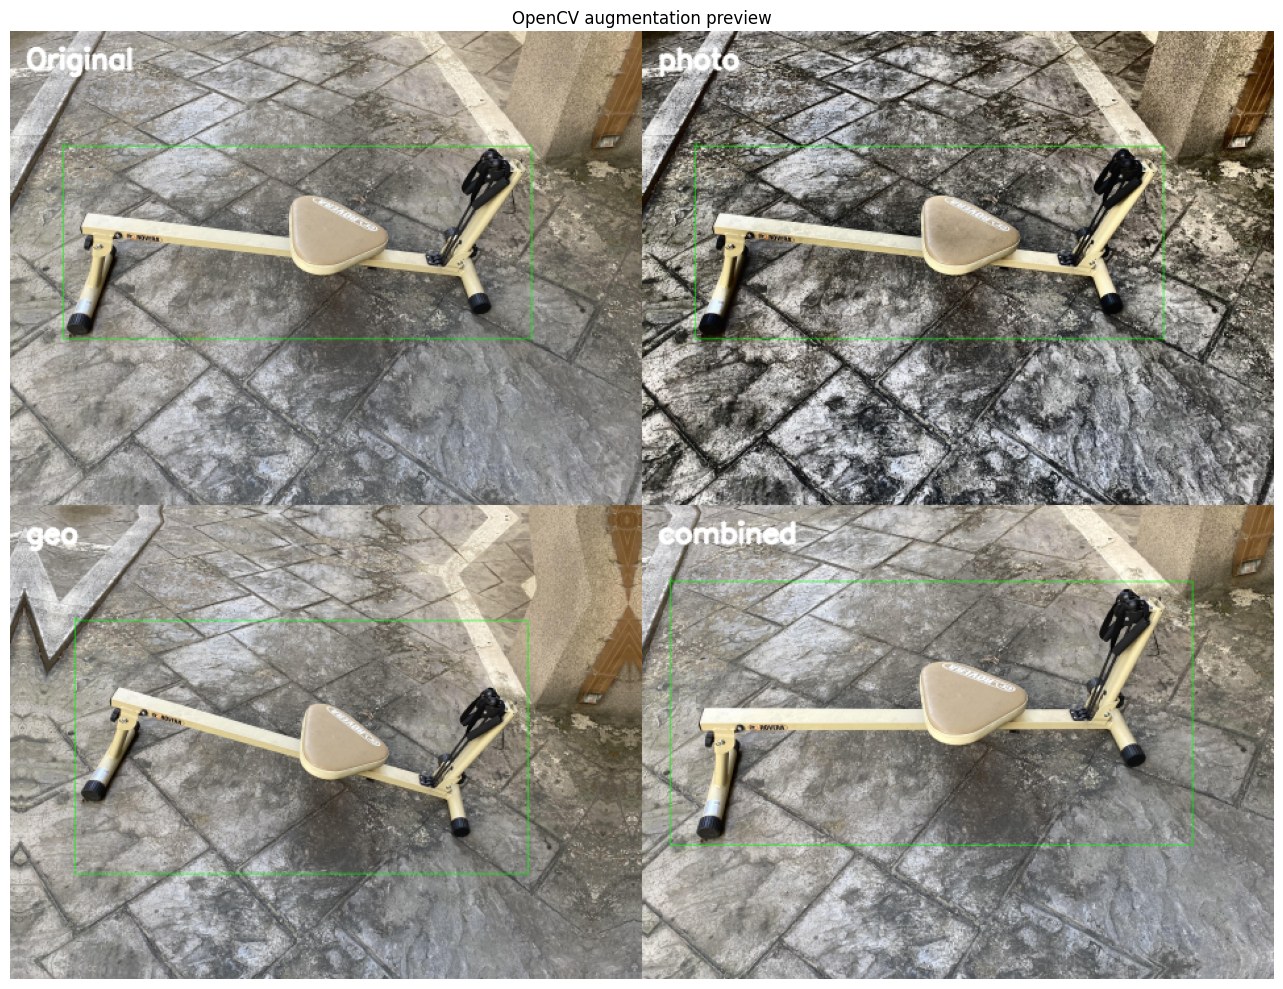

In [26]:
def resize_for_gallery(img, target_w=480, target_h=360):
    h, w = img.shape[:2]
    scale = min(target_w / w, target_h / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((target_h, target_w, 3), 30, dtype=np.uint8)
    x0 = (target_w - nw) // 2
    y0 = (target_h - nh) // 2
    canvas[y0:y0+nh, x0:x0+nw] = resized
    return canvas


def make_gallery(items, cols=2):
    thumbs = []
    for title, img in items:
        thumb = resize_for_gallery(img)
        cv2.putText(thumb, title, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
        thumbs.append(thumb)
    rows=[]
    for i in range(0, len(thumbs), cols):
        row=thumbs[i:i+cols]
        while len(row)<cols:
            row.append(np.full_like(thumbs[0],30))
        rows.append(cv2.hconcat(row))
    return cv2.vconcat(rows)

base_img = cv2.imread(str(img_path))
h, w = base_img.shape[:2]
base_classes, base_boxes = read_yolo_label(lbl_path, w, h)

items = [("Original", draw_boxes(base_img, base_boxes, base_classes))]
for idx, (name, fn) in enumerate(CV2_POLICIES.items(), start=1):
    rng = np.random.default_rng(SEED + idx)
    aug_img, aug_boxes, aug_classes = fn(base_img, base_boxes, base_classes, rng)
    items.append((name, draw_boxes(aug_img, aug_boxes, aug_classes)))

gallery = make_gallery(items, cols=2)
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(gallery, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("OpenCV augmentation preview")
plt.tight_layout()
plt.show()

## 7-2. 기하 증강 bbox 보존율 QA

증강이 강해서 bbox가 대량으로 잘려 나가면 실험 자체가 왜곡됩니다. 먼저 좌표 변환만 반복해 retention을 확인합니다.

In [27]:
def geo_retention_qa():
    rows=[]
    train_images = processed_image_df[processed_image_df["processed_split"].eq("train")]
    grouped = processed_object_df.groupby("image_name")

    total_in=0
    total_out=0
    clipped_kept=0

    for row in train_images.itertuples(index=False):
        if row.image_name not in grouped.groups:
            continue
        g = grouped.get_group(row.image_name)
        boxes = g[["x1","y1","x2","y2"]].to_numpy(np.float32)
        total_in += len(boxes)

        seed = int(hashlib.sha1(f"geo|{row.image_name}".encode()).hexdigest()[:8], 16)
        rng = np.random.default_rng(seed)
        h, w = int(row.height), int(row.width)

        angle = float(rng.uniform(-12, 12))
        scale = float(rng.uniform(0.88, 1.12))
        tx = float(rng.uniform(-0.06, 0.06) * w)
        ty = float(rng.uniform(-0.06, 0.06) * h)
        matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
        matrix[0,2] += tx
        matrix[1,2] += ty
        boxes2, keep, visible = transform_boxes(boxes, matrix, w, h)
        total_out += len(boxes2)
        if len(visible):
            clipped_kept += int((visible[keep] < 0.999).sum())

    return pd.DataFrame([{
        "policy": "affine stage of geo",
        "input_boxes": total_in,
        "output_boxes": total_out,
        "retention_pct": 100 * total_out / max(total_in, 1),
        "kept_but_clipped": clipped_kept,
    }])

cv2_retention = geo_retention_qa()
display(cv2_retention)
cv2_retention.to_csv(REPORT_DIR / "cv2_bbox_retention_qa.csv", index=False, encoding="utf-8-sig")

,policy,input_boxes,output_boxes,retention_pct,kept_but_clipped
0,affine stage of geo,853,853,100.0,52


# 8. OpenCV offline augmented dataset 생성기

OpenCV 실험은 validation을 건드리지 않고 **원본 train + 증강 train**을 함께 학습합니다. 각 실험에 필요한 정책만 on-demand로 생성하므로 모든 증강본을 미리 만들 필요가 없습니다.

In [28]:
def xyxy_to_yolo_lines(classes, boxes, width, height):
    lines=[]
    for cls, (x1,y1,x2,y2) in zip(classes, boxes):
        xc,yc,bw,bh = xyxy_to_yolo(x1,y1,x2,y2,width,height)
        lines.append(f"{int(cls)} {xc:.8f} {yc:.8f} {bw:.8f} {bh:.8f}")
    return lines


def build_offline_aug_dataset(policy_name: str, copies_per_image=1, overwrite=False):
    if policy_name not in CV2_POLICIES:
        raise KeyError(policy_name)

    img_dir = DATASET_DIR / "images" / f"train_cv2_{policy_name}"
    lbl_dir = DATASET_DIR / "labels" / f"train_cv2_{policy_name}"

    if overwrite:
        shutil.rmtree(img_dir, ignore_errors=True)
        shutil.rmtree(lbl_dir, ignore_errors=True)
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    fn = CV2_POLICIES[policy_name]
    rows=[]

    for src_img in sorted((DATASET_DIR / "images" / "train").glob("*.*")):
        src_lbl = DATASET_DIR / "labels" / "train" / f"{src_img.stem}.txt"
        image = cv2.imread(str(src_img))
        if image is None:
            continue
        h,w=image.shape[:2]
        classes,boxes=read_yolo_label(src_lbl,w,h)

        for copy_idx in range(copies_per_image):
            seed_text=f"{SEED}|{policy_name}|{src_img.name}|{copy_idx}"
            seed=int(hashlib.sha1(seed_text.encode()).hexdigest()[:8],16)
            rng=np.random.default_rng(seed)
            aug_img,aug_boxes,aug_classes=fn(image,boxes,classes,rng)

            if len(classes)>0 and len(aug_classes)==0:
                continue

            suffix=f"__{policy_name}{copy_idx+1}"
            out_img=img_dir/f"{src_img.stem}{suffix}{src_img.suffix.lower()}"
            out_lbl=lbl_dir/f"{src_img.stem}{suffix}.txt"
            if not cv2.imwrite(str(out_img),aug_img):
                raise IOError(out_img)
            out_lbl.write_text("\n".join(xyxy_to_yolo_lines(aug_classes,aug_boxes,w,h)),encoding="utf-8")
            rows.append({
                "policy":policy_name,
                "source_image":src_img.name,
                "aug_image":out_img.name,
                "source_objects":len(classes),
                "aug_objects":len(aug_classes),
            })

    report=pd.DataFrame(rows)
    report.to_csv(REPORT_DIR/f"cv2_{policy_name}_generation.csv",index=False,encoding="utf-8-sig")

    data_yaml={
        "path":str(DATASET_DIR.resolve()),
        "train":["images/train",f"images/train_cv2_{policy_name}"],
        "val":"images/val",
        "names":{i:name for i,name in enumerate(TARGET_CLASSES)},
    }
    yaml_path=DATASET_DIR/f"data_cv2_{policy_name}.yaml"
    with open(yaml_path,"w",encoding="utf-8") as f:
        yaml.safe_dump(data_yaml,f,allow_unicode=True,sort_keys=False)
    return yaml_path,report

# 예시: 실제 offline dataset은 해당 실험 직전에 runner가 자동 생성합니다.

# 9. YOLO baseline 및 증강 실험 설계

## 비교 원칙

- 모든 run은 동일 pretrained nano model에서 새로 시작
- 같은 clean train/validation split 사용
- 같은 `imgsz`, batch, epoch, seed
- validation augmentation 없음
- **1차 순위 지표: mAP50-95**
- Recall / Precision / mAP50 / 학습시간도 같이 확인
- 클래스 이미지 균형이 이미 개선되었으므로 augmentation 비교에서는 class weighting을 섞지 않음

## 실험 구성

| ID | 데이터 | YOLO 증강 | 목적 |
|---|---|---|---|
| E00 | 원본 | 모두 off | 순수 control |
| E01 | 원본 | Ultralytics default | 실용 baseline |
| E02 | 원본 | HSV + flip | 색/밝기 변화 효과 |
| E03 | 원본 | light geometry | 위치/크기/각도 변화 효과 |
| E04 | 원본 | HSV + geometry | 일반적인 조합 |
| E05 | 원본 | HSV + geometry + mosaic | 작은 데이터에서 mosaic 효과 |
| E06 | 원본 | E05 + MixUp | 혼합 증강 추가 효과 |
| E07 | 원본 | E05 + CutMix | CutMix 추가 효과 |
| E08 | 원본 + OpenCV photo | YOLO off | OpenCV photometric 독립 효과 |
| E09 | 원본 + OpenCV geo | YOLO off | OpenCV geometric 독립 효과 |
| E10 | 원본 + OpenCV combined | 약한 YOLO 증강 | offline + online 조합 효과 |

`mosaic`, `mixup`, `cutmix`, HSV, flip, degrees/translate/scale/shear/perspective는 Ultralytics train augmentation 인자로 전달합니다. 설치된 버전에서 지원하지 않는 인자는 runner가 확인 후 자동 제외하도록 작성했습니다.

In [29]:
DATA_YAML = DATASET_DIR / "data.yaml"

NO_AUG = {
    "hsv_h": 0.0, "hsv_s": 0.0, "hsv_v": 0.0,
    "degrees": 0.0, "translate": 0.0, "scale": 0.0,
    "shear": 0.0, "perspective": 0.0,
    "flipud": 0.0, "fliplr": 0.0,
    "bgr": 0.0,
    "mosaic": 0.0, "mixup": 0.0, "cutmix": 0.0,
    "copy_paste": 0.0,
}

YOLO_PHOTO = {
    **NO_AUG,
    "hsv_h": 0.015,
    "hsv_s": 0.50,
    "hsv_v": 0.35,
    "fliplr": 0.50,
}

YOLO_GEO = {
    **NO_AUG,
    "degrees": 10.0,
    "translate": 0.08,
    "scale": 0.25,
    "shear": 2.0,
    "perspective": 0.0003,
    "fliplr": 0.50,
}

YOLO_PHOTO_GEO = {
    **YOLO_GEO,
    "hsv_h": 0.015,
    "hsv_s": 0.50,
    "hsv_v": 0.35,
}

YOLO_MOSAIC = {
    **YOLO_PHOTO_GEO,
    "mosaic": 0.70,
}

YOLO_MIXUP = {
    **YOLO_MOSAIC,
    "mixup": 0.10,
}

YOLO_CUTMIX = {
    **YOLO_MOSAIC,
    "cutmix": 0.10,
}

YOLO_LIGHT_AFTER_CV2 = {
    **NO_AUG,
    "hsv_h": 0.010,
    "hsv_s": 0.25,
    "hsv_v": 0.20,
    "degrees": 5.0,
    "translate": 0.04,
    "scale": 0.12,
    "fliplr": 0.35,
}

EXPERIMENTS = [
    {"id":"E00","name":"no_aug_control","offline":None,"aug":NO_AUG,"description":"all controllable YOLO augmentation off"},
    {"id":"E01","name":"yolo_default","offline":None,"aug":None,"description":"Ultralytics default augmentation"},
    {"id":"E02","name":"yolo_photo","offline":None,"aug":YOLO_PHOTO,"description":"HSV + horizontal flip"},
    {"id":"E03","name":"yolo_geo","offline":None,"aug":YOLO_GEO,"description":"light geometry + flip"},
    {"id":"E04","name":"yolo_photo_geo","offline":None,"aug":YOLO_PHOTO_GEO,"description":"HSV + light geometry"},
    {"id":"E05","name":"yolo_mosaic","offline":None,"aug":YOLO_MOSAIC,"description":"HSV + geometry + mosaic"},
    {"id":"E06","name":"yolo_mosaic_mixup","offline":None,"aug":YOLO_MIXUP,"description":"mosaic + MixUp"},
    {"id":"E07","name":"yolo_mosaic_cutmix","offline":None,"aug":YOLO_CUTMIX,"description":"mosaic + CutMix"},
    {"id":"E08","name":"cv2_photo","offline":"photo","aug":NO_AUG,"description":"original + OpenCV photometric"},
    {"id":"E09","name":"cv2_geo","offline":"geo","aug":NO_AUG,"description":"original + OpenCV geometry"},
    {"id":"E10","name":"cv2_combined_yolo_light","offline":"combined","aug":YOLO_LIGHT_AFTER_CV2,"description":"OpenCV combined + weak YOLO online aug"},
]

planned_experiments = pd.DataFrame([
    {
        "id":e["id"],
        "name":e["name"],
        "offline_cv2":e["offline"] or "-",
        "yolo_aug": "Ultralytics defaults" if e["aug"] is None else json.dumps(e["aug"], ensure_ascii=False),
        "description":e["description"],
    }
    for e in EXPERIMENTS
])
display(planned_experiments[["id","name","offline_cv2","description"]])

,id,name,offline_cv2,description
0,E00,no_aug_control,-,all controllable YOLO augmentation off
1,E01,yolo_default,-,Ultralytics default augmentation
2,E02,yolo_photo,-,HSV + horizontal flip
3,E03,yolo_geo,-,light geometry + flip
4,E04,yolo_photo_geo,-,HSV + light geometry
5,E05,yolo_mosaic,-,HSV + geometry + mosaic
6,E06,yolo_mosaic_mixup,-,mosaic + MixUp
7,E07,yolo_mosaic_cutmix,-,mosaic + CutMix
8,E08,cv2_photo,photo,original + OpenCV photometric
9,E09,cv2_geo,geo,original + OpenCV geometry


# 10. YOLO baseline 코드

설치 관련 셀은 두지 않았습니다. `RUN_TRAINING=True`일 때 현재 선택된 Jupyter 커널의 `ultralytics`를 그대로 사용합니다.

In [30]:
def get_yolo_runtime():
    from ultralytics import YOLO
    from ultralytics.cfg import DEFAULT_CFG_DICT
    import torch
    import ultralytics

    if torch.cuda.is_available():
        device = 0
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"

    return YOLO, DEFAULT_CFG_DICT, torch, ultralytics, device


def baseline_train_example():
    YOLO, DEFAULT_CFG_DICT, torch, ultralytics, device = get_yolo_runtime()
    model = YOLO(MODEL_NAME)
    return model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        device=device,
        seed=SEED,
        deterministic=True,
        patience=PATIENCE,
        project=str(RUNS_DIR),
        name="baseline_no_aug_example",
        plots=True,
        **{k:v for k,v in NO_AUG.items() if k in DEFAULT_CFG_DICT},
    )

# 단일 baseline만 먼저 돌리고 싶을 때:
# baseline_result = baseline_train_example()

# 11. 전체 증강 실험 자동 runner

실행 순서:

1. 설정 셀의 `RUN_TRAINING=True`
2. 이 셀 실행
3. `reports/experiment_summary.csv` 자동 생성

OpenCV offline 실험(E08~E10)은 필요한 증강 데이터셋을 그 실험 직전에 자동 생성합니다.

In [31]:
def filter_supported_aug_args(args, default_cfg):
    if args is None:
        return None, []
    supported=set(default_cfg.keys())
    unknown=sorted(set(args)-supported)
    clean={k:v for k,v in args.items() if k in supported}
    return clean, unknown


def extract_box_metrics(metrics):
    box=metrics.box
    return {
        "precision":float(box.mp),
        "recall":float(box.mr),
        "mAP50":float(box.map50),
        "mAP50_95":float(box.map),
    }


def train_one_experiment(exp, seed=SEED, epochs=EPOCHS):
    YOLO, DEFAULT_CFG_DICT, torch, ultralytics, device = get_yolo_runtime()

    if exp["offline"]:
        data_path = DATASET_DIR / f'data_cv2_{exp["offline"]}.yaml'
        if not data_path.exists():
            data_path, report = build_offline_aug_dataset(
                exp["offline"], copies_per_image=CV2_AUG_COPIES, overwrite=True
            )
            print(f'OpenCV {exp["offline"]}: generated {len(report)} augmented images')
    else:
        data_path=DATA_YAML

    aug_args, unknown = filter_supported_aug_args(exp["aug"], DEFAULT_CFG_DICT)
    if unknown:
        print("Unsupported args in current Ultralytics version -> skipped:", unknown)

    run_name=f'{exp["id"]}_{exp["name"]}_seed{seed}'
    model=YOLO(MODEL_NAME)

    kwargs=dict(
        data=str(data_path),
        epochs=epochs,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        device=device,
        seed=seed,
        deterministic=True,
        patience=PATIENCE,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        plots=True,
        save=True,
        verbose=True,
    )
    if aug_args is not None:
        kwargs.update(aug_args)

    started=time.perf_counter()
    train_result=model.train(**kwargs)
    elapsed_min=(time.perf_counter()-started)/60.0

    save_dir=Path(train_result.save_dir)
    best_pt=save_dir/"weights"/"best.pt"
    if not best_pt.exists():
        raise FileNotFoundError(best_pt)

    best_model=YOLO(str(best_pt))
    val_metrics=best_model.val(
        data=str(data_path), split="val", imgsz=IMGSZ,
        batch=BATCH, workers=WORKERS, device=device,
        plots=True, verbose=False,
    )

    return {
        "id":exp["id"],
        "name":exp["name"],
        "description":exp["description"],
        "offline_cv2":exp["offline"] or "-",
        "seed":seed,
        "epochs":epochs,
        "model_name":MODEL_NAME,
        "ultralytics_version":ultralytics.__version__,
        "torch_version":torch.__version__,
        "device":str(device),
        "train_minutes":elapsed_min,
        "data_yaml":str(data_path),
        "save_dir":str(save_dir),
        "best_pt":str(best_pt),
        **extract_box_metrics(val_metrics),
    }


def run_experiments(experiments=EXPERIMENTS, seed=SEED, epochs=EPOCHS):
    rows=[]
    out_csv=REPORT_DIR/"experiment_summary.csv"

    for idx,exp in enumerate(experiments,1):
        print("="*90)
        print(f'[{idx}/{len(experiments)}] {exp["id"]} {exp["name"]}')
        try:
            row=train_one_experiment(exp,seed=seed,epochs=epochs)
        except Exception as e:
            row={
                "id":exp["id"],"name":exp["name"],"seed":seed,
                "description":exp["description"],"error":repr(e),
            }
            print("FAILED:",repr(e))
        rows.append(row)
        pd.DataFrame(rows).to_csv(out_csv,index=False,encoding="utf-8-sig")
        display(pd.DataFrame(rows).tail())

    return pd.DataFrame(rows)

if RUN_TRAINING:
    experiment_results = run_experiments()
else:
    print("RUN_TRAINING=False — 전처리/EDA/증강 QA까지만 실행했습니다.")
    print("YOLO 실험을 시작할 때 RUN_TRAINING=True로 변경하세요.")

RUN_TRAINING=False — 전처리/EDA/증강 QA까지만 실행했습니다.
YOLO 실험을 시작할 때 RUN_TRAINING=True로 변경하세요.


# 12. 결과 표 자동 정리

성공한 실험을 `mAP50-95` 기준으로 정렬하고 E00 control 대비 개선폭도 계산합니다.

In [32]:
SUMMARY_CSV=REPORT_DIR/"experiment_summary.csv"

if SUMMARY_CSV.exists():
    results_df=pd.read_csv(SUMMARY_CSV)
    valid=results_df.dropna(subset=["mAP50_95"]).copy() if "mAP50_95" in results_df.columns else pd.DataFrame()

    if len(valid):
        valid=valid.sort_values("mAP50_95",ascending=False)
        control=valid[valid["id"].eq("E00")]
        control_map=float(control.iloc[0]["mAP50_95"]) if len(control) else np.nan
        valid["mAP50_95_delta_vs_E00"]=valid["mAP50_95"]-control_map
        valid["rank"]=np.arange(1,len(valid)+1)

        result_table=valid[[
            "rank","id","name","precision","recall","mAP50","mAP50_95",
            "mAP50_95_delta_vs_E00","train_minutes","best_pt"
        ]]
        display(result_table)
        result_table.to_csv(REPORT_DIR/"experiment_ranking.csv",index=False,encoding="utf-8-sig")
    else:
        print("아직 성공한 YOLO 결과가 없습니다.")
        display(results_df)
else:
    print("아직 experiment_summary.csv가 없습니다. 아래는 실행 예정 실험입니다.")
    display(planned_experiments[["id","name","offline_cv2","description"]])

아직 experiment_summary.csv가 없습니다. 아래는 실행 예정 실험입니다.


,id,name,offline_cv2,description
0,E00,no_aug_control,-,all controllable YOLO augmentation off
1,E01,yolo_default,-,Ultralytics default augmentation
2,E02,yolo_photo,-,HSV + horizontal flip
3,E03,yolo_geo,-,light geometry + flip
4,E04,yolo_photo_geo,-,HSV + light geometry
5,E05,yolo_mosaic,-,HSV + geometry + mosaic
6,E06,yolo_mosaic_mixup,-,mosaic + MixUp
7,E07,yolo_mosaic_cutmix,-,mosaic + CutMix
8,E08,cv2_photo,photo,original + OpenCV photometric
9,E09,cv2_geo,geo,original + OpenCV geometry


# 13. 결과 시각화

In [33]:
if SUMMARY_CSV.exists():
    results_df=pd.read_csv(SUMMARY_CSV)
    if "mAP50_95" in results_df.columns:
        valid=results_df.dropna(subset=["mAP50_95"]).copy()
        if len(valid):
            plot_df=valid.sort_values("mAP50_95",ascending=True)
            plt.figure(figsize=(11,7))
            plt.barh(plot_df["name"],plot_df["mAP50_95"])
            plt.xlabel("mAP50-95")
            plt.ylabel("Experiment")
            plt.title("Augmentation experiment ranking")
            plt.tight_layout()
            plt.show()

In [34]:
if SUMMARY_CSV.exists():
    results_df=pd.read_csv(SUMMARY_CSV)
    if "mAP50" in results_df.columns:
        valid=results_df.dropna(subset=["mAP50"]).copy()
        if len(valid):
            plot_df=valid.sort_values("mAP50",ascending=True)
            plt.figure(figsize=(11,7))
            plt.barh(plot_df["name"],plot_df["mAP50"])
            plt.xlabel("mAP50")
            plt.ylabel("Experiment")
            plt.title("mAP50 by experiment")
            plt.tight_layout()
            plt.show()

In [35]:
if SUMMARY_CSV.exists():
    results_df=pd.read_csv(SUMMARY_CSV)
    needed={"precision","recall","name"}
    if needed.issubset(results_df.columns):
        valid=results_df.dropna(subset=["precision","recall"]).copy()
        if len(valid):
            x=np.arange(len(valid))
            width=0.38
            plt.figure(figsize=(12,6))
            plt.bar(x-width/2,valid["precision"],width=width,label="Precision")
            plt.bar(x+width/2,valid["recall"],width=width,label="Recall")
            plt.xticks(x,valid["name"],rotation=45,ha="right")
            plt.ylabel("Score")
            plt.title("Precision and Recall")
            plt.legend()
            plt.tight_layout()
            plt.show()

In [36]:
if SUMMARY_CSV.exists():
    results_df=pd.read_csv(SUMMARY_CSV)
    needed={"mAP50_95","train_minutes","name"}
    if needed.issubset(results_df.columns):
        valid=results_df.dropna(subset=["mAP50_95","train_minutes"]).copy()
        if len(valid):
            plt.figure(figsize=(9,6))
            plt.scatter(valid["train_minutes"],valid["mAP50_95"])
            for _,r in valid.iterrows():
                plt.annotate(r["id"],(r["train_minutes"],r["mAP50_95"]))
            plt.xlabel("Training minutes")
            plt.ylabel("mAP50-95")
            plt.title("Accuracy vs training time")
            plt.tight_layout()
            plt.show()

# 14. Best run의 학습 곡선·PR curve·confusion matrix

In [37]:
def show_if_exists(path: Path, width=1000):
    if path.exists():
        print(path)
        display(IPImage(filename=str(path),width=width))

if SUMMARY_CSV.exists():
    results_df=pd.read_csv(SUMMARY_CSV)
    if "mAP50_95" in results_df.columns:
        valid=results_df.dropna(subset=["mAP50_95"]).copy()
        if len(valid):
            best=valid.sort_values("mAP50_95",ascending=False).iloc[0]
            best_dir=Path(best["save_dir"])
            print("Best:",best["id"],best["name"],"mAP50-95=",best["mAP50_95"])
            for filename in [
                "results.png",
                "PR_curve.png",
                "confusion_matrix_normalized.png",
                "val_batch0_pred.jpg",
            ]:
                show_if_exists(best_dir/filename)

# 15. Best model의 클래스별 AP + validation support

전체 mAP만 보면 희소/미평가 클래스를 놓칠 수 있으므로 class AP와 실제 validation 객체 수를 같은 표에서 확인합니다.

In [38]:
def best_model_per_class_report():
    YOLO, DEFAULT_CFG_DICT, torch, ultralytics, device = get_yolo_runtime()
    if not SUMMARY_CSV.exists():
        raise FileNotFoundError(SUMMARY_CSV)

    results=pd.read_csv(SUMMARY_CSV).dropna(subset=["mAP50_95"])
    if not len(results):
        raise RuntimeError("No successful experiment")

    best=results.sort_values("mAP50_95",ascending=False).iloc[0]
    model=YOLO(best["best_pt"])
    metrics=model.val(
        data=str(DATA_YAML),split="val",imgsz=IMGSZ,batch=BATCH,
        workers=WORKERS,device=device,verbose=False,
    )

    maps=np.asarray(metrics.box.maps,dtype=float)
    report=pd.DataFrame({
        "class_id":range(len(TARGET_CLASSES)),
        "class_name":TARGET_CLASSES,
        "AP50_95":maps,
    })
    support=processed_support["val"].rename("val_objects")
    report=report.join(support,on="class_name")
    report["evaluable_on_val"]=report["val_objects"].gt(0)
    report=report.sort_values(["evaluable_on_val","AP50_95"],ascending=[False,False])
    report.to_csv(REPORT_DIR/"best_per_class_ap.csv",index=False,encoding="utf-8-sig")
    return report

# YOLO 실험 완료 후:
# per_class_report = best_model_per_class_report()
# display(per_class_report)

# 16. 상위 2개 증강 조합 multi-seed 재검증

클래스당 이미지가 아직 많지 않기 때문에 seed 하나에 결과가 흔들릴 수 있습니다. 1차 실험에서 상위 2개만 골라 `42, 123, 777` 세 seed로 다시 학습하고 평균·표준편차를 비교합니다.

In [39]:
def run_top2_multiseed():
    if not SUMMARY_CSV.exists():
        raise FileNotFoundError("Run first-stage experiments first")

    first=pd.read_csv(SUMMARY_CSV).dropna(subset=["mAP50_95"])
    top_ids=(
        first.sort_values("mAP50_95",ascending=False)
        .drop_duplicates("id")
        .head(2)["id"].tolist()
    )
    top_exps=[e for e in EXPERIMENTS if e["id"] in top_ids]
    rows=[]

    for exp in top_exps:
        for seed in MULTI_SEEDS:
            print("="*90)
            print(exp["id"],exp["name"],"seed",seed)
            rows.append(train_one_experiment(exp,seed=seed,epochs=EPOCHS))
            pd.DataFrame(rows).to_csv(REPORT_DIR/"top2_multiseed_raw.csv",index=False,encoding="utf-8-sig")

    raw=pd.DataFrame(rows)
    summary=(
        raw.groupby(["id","name"])
        .agg(
            runs=("mAP50_95","count"),
            mAP50_95_mean=("mAP50_95","mean"),
            mAP50_95_std=("mAP50_95","std"),
            mAP50_mean=("mAP50","mean"),
            precision_mean=("precision","mean"),
            recall_mean=("recall","mean"),
            train_minutes_mean=("train_minutes","mean"),
        )
        .reset_index()
        .sort_values("mAP50_95_mean",ascending=False)
    )
    summary.to_csv(REPORT_DIR/"top2_multiseed_summary.csv",index=False,encoding="utf-8-sig")
    return raw,summary

if RUN_MULTISEED:
    multiseed_raw,multiseed_summary=run_top2_multiseed()
    display(multiseed_summary)
else:
    print("RUN_MULTISEED=False")

RUN_MULTISEED=False


# 17. 결과 자동 결론문

실험이 완료되면 가장 좋은 단일 run과 baseline 대비 개선폭을 간단히 요약합니다. 발표에서는 multi-seed 결과가 있으면 단일 run보다 multi-seed 평균을 우선하세요.

In [40]:
if SUMMARY_CSV.exists():
    results=pd.read_csv(SUMMARY_CSV)
    if "mAP50_95" in results.columns:
        valid=results.dropna(subset=["mAP50_95"]).copy()
        if len(valid):
            best=valid.sort_values("mAP50_95",ascending=False).iloc[0]
            control=valid[valid["id"].eq("E00")]
            delta=np.nan
            if len(control):
                delta=float(best["mAP50_95"]-control.iloc[0]["mAP50_95"])

            text=(
                f"### 단일 seed 실험 요약\n\n"
                f"- Best: **{best['id']} {best['name']}**\n"
                f"- mAP50-95: **{best['mAP50_95']:.4f}**\n"
                f"- mAP50: **{best['mAP50']:.4f}**\n"
                f"- Precision: **{best['precision']:.4f}**\n"
                f"- Recall: **{best['recall']:.4f}**\n"
            )
            if not np.isnan(delta):
                text += f"- E00 대비 mAP50-95 변화: **{delta:+.4f}**\n"
            display(Markdown(text))

# 18. 해석 가이드와 최종 권장 절차

## 현재 데이터에서 확인된 점

1. **이전 5장/클래스 데이터보다 Training이 크게 증가함**  
   실제 ZIP 기준 Training은 766장입니다. 86개 소분류 중 84개는 9장씩이며, 원본 매칭 가능 샘플이 5개뿐인 `의류/기타`, `캔류/기타`는 각각 5장입니다.

2. **Validation은 3개 클래스가 구조적으로 없음**  
   `의류/기타`, `캔류/기타`, `형광등/기타`의 클래스별 AP는 이 validation으로 판단하지 않습니다. 나머지 83개 클래스는 각 2장씩이라 클래스별 AP의 분산도 여전히 큽니다.

3. **객체 단위 support는 완전히 동일하지 않음**  
   다중 객체 이미지와 폴더-JSON 불일치 때문에 bbox 수는 클래스마다 다릅니다. clean 전처리 후 Training 객체는 853개, Validation 객체는 178개이며, Training 클래스별 객체 수는 5~18개 범위입니다.

4. **대부분 9장/클래스도 충분히 큰 학습량은 아님**  
   이전보다 분명 개선되었지만 증강은 새로운 촬영 환경 자체를 만들어내는 것이 아니라 기존 이미지의 변형입니다. 최종 모델에서는 실제 원본 데이터를 더 늘리는 것이 가장 중요합니다.

5. **모든 데이터가 주간**  
   서비스가 야간/저조도 사진도 받는다면 밝기 증강만으로 실제 야간 분포를 완전히 대체할 수 없습니다.

6. **증강을 많이 넣는 것이 항상 좋은 것은 아님**  
   특히 mosaic/MixUp/CutMix가 실제 사용자 촬영 분포와 너무 멀어지면 오히려 성능이 낮아질 수 있으므로 E00~E10 ablation으로 검증합니다.

## 권장 실험 순서

1. E00~E10 동일 seed로 1차 screening
2. `mAP50-95` 상위 2개 선정
3. 상위 2개를 3-seed 재학습
4. 평균 mAP50-95 + 표준편차 + Recall을 함께 비교
5. 더 큰 Training 데이터로 상위 조합만 재검증
6. 최종적으로 별도 Test set에서 1회 평가

## 서비스 관점에서 Recall도 중요

현재 UX가 사진에서 여러 후보 bbox를 먼저 찾아 사용자가 물건을 선택하는 흐름이라면, 정답 후보를 놓치지 않는 Recall이 중요합니다. 따라서 mAP50-95가 비슷한 두 모델이라면 Recall이 더 높은 쪽을 우선 검토할 가치가 있습니다.

# 19. 실행 후 생성되는 주요 산출물

```text
yolo_train10_val2_experiment/
├─ dataset/
│  ├─ data.yaml
│  ├─ class_mapping.csv
│  ├─ image_report.csv
│  ├─ object_report.csv
│  ├─ excluded_images.csv
│  ├─ images/train, images/val
│  └─ labels/train, labels/val
├─ reports/
│  ├─ cv2_bbox_retention_qa.csv
│  ├─ cv2_*_generation.csv
│  ├─ experiment_summary.csv
│  ├─ experiment_ranking.csv
│  ├─ best_per_class_ap.csv
│  ├─ top2_multiseed_raw.csv
│  └─ top2_multiseed_summary.csv
└─ runs/
   └─ E00_... ~ E10_...
```

### 팀 공유 시 핵심 파일

- `dataset/excluded_images.csv`: 제외한 라벨 불일치 6장
- `reports/experiment_ranking.csv`: 증강 조합별 성능 순위
- `reports/top2_multiseed_summary.csv`: 상위 조합 안정성
- `reports/best_per_class_ap.csv`: 클래스별 AP + validation support
- best run의 `results.png`, `PR_curve.png`, `confusion_matrix_normalized.png`

# 20. 참고 문서

- Ultralytics Train mode: https://docs.ultralytics.com/modes/train/
- Ultralytics annotated-data preprocessing / augmentation: https://docs.ultralytics.com/guides/preprocessing-annotated-data/
- Ultralytics Python usage: https://docs.ultralytics.com/usage/python/

이 노트북의 증강 설정은 dataset YAML이 아니라 `model.train()`의 augmentation 인자로 전달하도록 구성했습니다.